<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
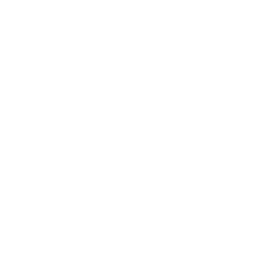
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analiza Trendu EWMA Wskaźnika Błędów Lekowych</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ochrona Zdrowia / Bezpieczeństwo Pacjenta &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie Wykonawcze

Ta analiza monitoruje tygodniowy wskaźnik błędów lekowych na oddziale intensywnej terapii (OIT) szpitala za pomocą **karty kontrolnej wykładniczo ważonej średniej ruchomej (EWMA)** z PROC MACONTROL. OIT wdrożył nowy system elektronicznej dokumentacji podawania leków (eMAR) w 51. tygodniu okresu obserwacji. Zespoły ds. bezpieczeństwa pacjenta potrzebują metody wczesnego ostrzegania, która szybko wykryje trwały wzrost liczby błędów, zanim zgromadzi się kwartał raportów o zdarzeniach niepożądanych.

Karta EWMA z wagą wygładzania **lambda = 0,3** jest budowana w dwóch fazach. Granice kontrolne są najpierw ustalane na podstawie stabilnej fazy wyjściowej sprzed migracji (tygodnie 1-50), a następnie cała 100-tygodniowa seria jest monitorowana względem tych ustalonych granic. Karta pozostaje pod kontrolą przez całą fazę wyjściową i sygnalizuje stan poza kontrolą **w pierwszym tygodniu po uruchomieniu systemu**, co potwierdza, że przejście na eMAR zbiegło się z realną, trwałą zmianą wskaźnika błędów, a nie ze zwykłym szumem tygodniowym.


## Źródła Danych

| Źródło | Opis | Rekordy |
|---------|-------------|---------|
| WORK.ICU_ERRORS | Tygodniowy wskaźnik błędów lekowych na 1000 podań dla jednego OIT, 100 kolejnych tygodni | 100 |

Jeden OIT jest śledzony tygodniowo. Każdy rekord zawiera numer tygodnia, wskaźnik błędów na 1000 podań, wolumen podań oraz wyliczoną liczbę błędów. Udokumentowana zmiana procesu (uruchomienie eMAR) następuje w 51. tygodniu, przesuwając bazową średnią wskaźnika błędów w górę o około 1,6 na 1000.


---

In [1]:
/* --------------------------------------------------------
   Generate weekly ICU medication-error data
   100 consecutive weeks for one ICU.
   A new eMAR system goes live at week 51, raising the
   underlying error-rate mean from ~3.5 to ~5.1 per 1,000.
   -------------------------------------------------------- */
DANE work.icu_errors;
    CALL streaminit(42);
    DŁUGOŚĆ unit_name $12 phase $12;
    unit_name = 'OIT';
    base_rate  = 3.5;   /* pre-migration mean rate / 1,000 */
    unit_sigma = 0.45;  /* week-to-week common-cause noise */
    POWTÓRZ week_num = 1 TO 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        JEŚLI administrations < 300 WTEDY administrations = 300;
        /* eMAR migration shifts the mean up after week 50 */
        JEŚLI week_num > 50 WTEDY POWTÓRZ;
            phase = 'PO-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            phase = 'WYJŚCIOWA';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        KONIEC;
        JEŚLI error_rate_per_1k < 0 WTEDY error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        WYJŚCIE;
    KONIEC;
    USUŃ base_rate unit_sigma;
    format week_start_date date9.;
WYKONAJ;



NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                Wskaźnik Błędów OIT: Faza Wyjściowa vs Po Wdrożeniu eMAR                                

                                                  The MEANS Procedure

                           Analysis Variable : error_rate_per_1k Wskaźnik błędów na 1000

        Faza                N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        PO-eMAR                50           5.11           0.44           3.69           5.96
        WYJŚCIOWA              50           3.50           0.48           2.55           4.71
        -------------------------------------------------------------------------------------

                                    Analysis Variable : error_count Liczba błędów

        Faza                N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


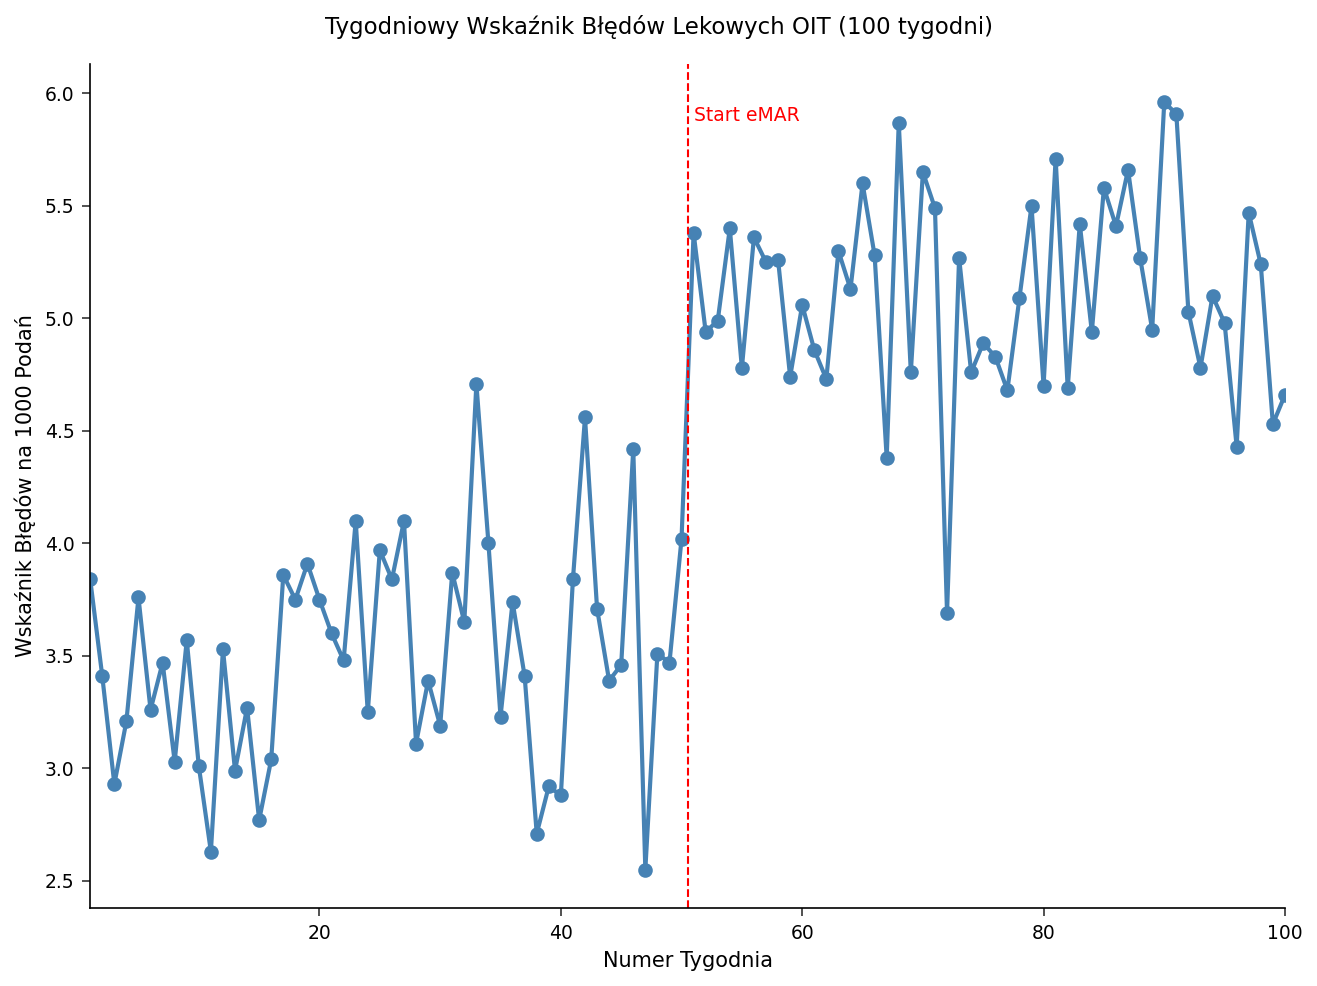

In [2]:
/* --------------------------------------------------------
   Compare the error rate before and after the eMAR
   go-live, and plot the weekly trend.
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.icu_errors n mean std MIN MAX maxdec=2;
    KLASA phase;
    ZMIENNA error_rate_per_1k error_count administrations;
    ETYKIETA phase = 'Faza' error_rate_per_1k = 'Wskaźnik błędów na 1000'
          error_count = 'Liczba błędów' administrations = 'Liczba podań';
    TYTUŁ 'Wskaźnik Błędów OIT: Faza Wyjściowa vs Po Wdrożeniu eMAR';
WYKONAJ;

PROCEDURA SGPLOT DANE=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   ETYKIETA='Start eMAR';
    XAXIS ETYKIETA='Numer Tygodnia';
    YAXIS ETYKIETA='Wskaźnik Błędów na 1000 Podań';
    TYTUŁ 'Tygodniowy Wskaźnik Błędów Lekowych OIT (100 tygodni)';
WYKONAJ;


---

In [3]:
/* --------------------------------------------------------
   Phase I: establish EWMA control limits from the stable
   pre-migration baseline (weeks 1-50). These fixed limits
   become the yardstick for the full monitoring period.
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.icu_errors(GDZIE=(week_num <= 50)) NOPRINT;
    ZMIENNA error_rate_per_1k;
    WYJŚCIE out=work.baseline_stats mean=base_mean std=base_std;
WYKONAJ;

DANE work.icu_limits;
    USTAW work.baseline_stats;
    DŁUGOŚĆ _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* baseline center line */
    _STDDEV_ = base_std;    /* baseline common-cause sigma */
    _LIMITN_ = 1;
    ZACHOWAJ _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.icu_limits noobs;
    TYTUŁ 'Dane Wejściowe Granic Kontrolnych - Faza I (tygodnie wyjściowe 1-50)';
WYKONAJ;


                          Dane Wejściowe Granic Kontrolnych - Faza I (tygodnie wyjściowe 1-50)                          

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                          Dane Wejściowe Granic Kontrolnych - Faza I (tygodnie wyjściowe 1-50)                          


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/951db3d2-7df7-45d9-ba28-6bf14b68ba97/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


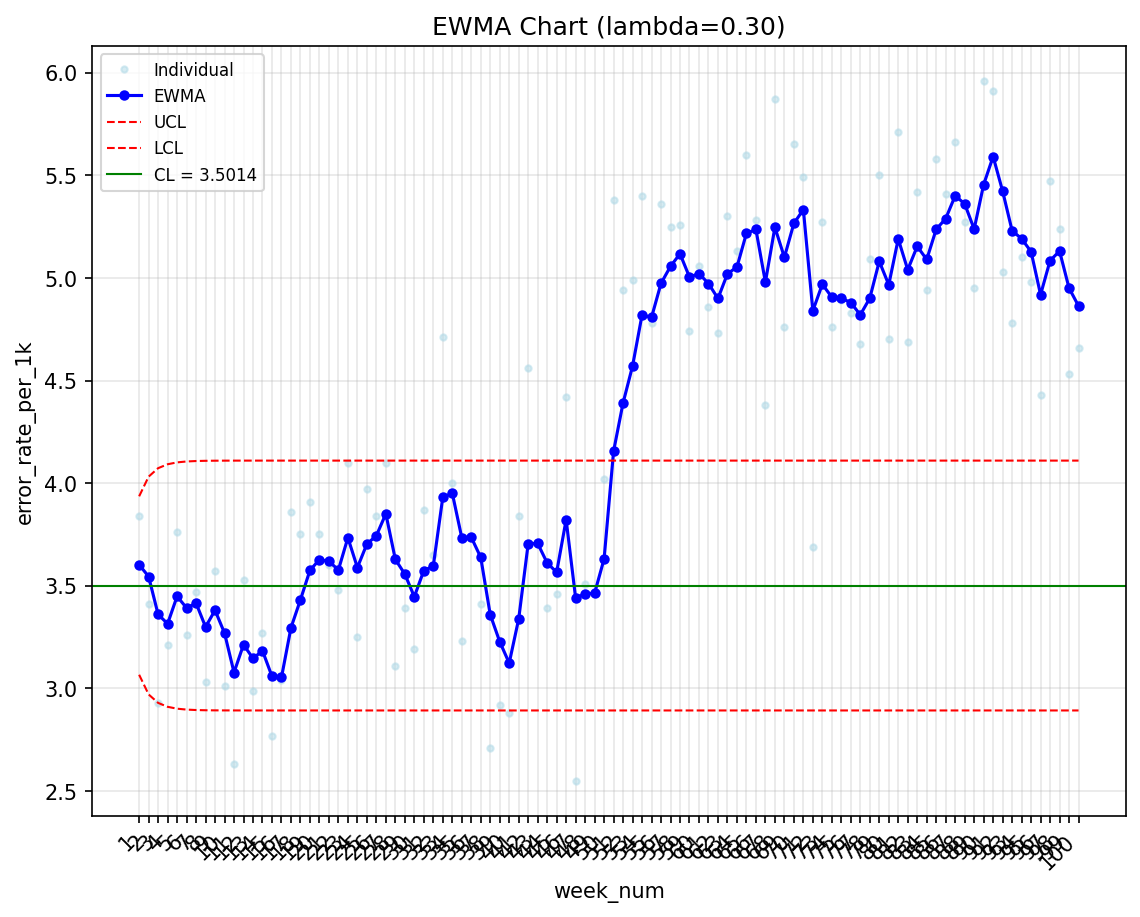

In [4]:
/* --------------------------------------------------------
   Phase II: monitor the full 100-week series against the
   fixed baseline limits. lambda=0.3 gives responsive
   detection appropriate for patient-safety surveillance.
   -------------------------------------------------------- */
PROCEDURA macontrol DANE=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        WAGA    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    ETYKIETA error_rate_per_1k =
          'Błędy Lekowe na 1000 Podań';
    TYTUŁ 'Karta EWMA: Wskaźnik Błędów Lekowych OIT (lambda=0,3)';
WYKONAJ;


---

In [5]:
/* --------------------------------------------------------
   Identify every week whose EWMA breaches the baseline
   limits and report when the chart first signals.
   -------------------------------------------------------- */
DANE work.signals;
    USTAW work.icu_table;
    GDZIE _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
WYKONAJ;

PROCEDURA SQL;
    WYBIERZ count(*)        AS n_signals          ETYKIETA='Tygodnie Sygnałowe',
           MIN(week_num)    AS first_signal_week  ETYKIETA='Pierwszy Tydzień Sygnału',
           MAX(_EWMA_)      AS peak_ewma format=6.3 ETYKIETA='Szczyt EWMA'
    FROM work.signals;
QUIT;

PROCEDURA DRUKUJ DANE=work.signals(obs=8);
    ZMIENNA week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    TYTUŁ 'Pierwsze Sygnały Poza Kontrolą EWMA';
WYKONAJ;


                          Dane Wejściowe Granic Kontrolnych - Faza I (tygodnie wyjściowe 1-50)                          

 Tygodnie Sygnałowe    Pierwszy Tydzień Sygnału  Szczyt EWMA
-------------------  --------------------------  -----------
                 50                        51.0        5.591
                                          Pierwsze Sygnały Poza Kontrolą EWMA                                           

  Obs  week_num    _EWMA_   _UCLE_  _EXLIM_
    1        51  4.155551  4.10998        1
    2        52  4.390886  4.10998        1
    3        53   4.57062  4.10998        1
    4        54  4.819434  4.10998        1
    5        55  4.807604  4.10998        1
    6        56  4.973323  4.10998        1
    7        57  5.056326  4.10998        1
    8        58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interpretacja

Dwufazowa analiza EWMA wyraźnie oddziela zwykłą zmienność tygodniową od realnej zmiany procesu w momencie uruchomienia eMAR.

**Faza wyjściowa (tygodnie 1-50).** PROC MEANS raportuje bazowy średni wskaźnik błędów na poziomie **3,50 na 1000 podań** (odchylenie standardowe 0,48), wobec średniej po migracji **5,11** (odchylenie standardowe 0,44) — trwałe przesunięcie w górę o około **1,6 błędu na 1000**. Wolumen podań jest porównywalny w obu fazach (795 vs 790 tygodniowo), więc zmiana odzwierciedla *wskaźnik* błędów, a nie wahania obciążenia pracą.

**Granice kontrolne.** Granice są ustalone wyłącznie na podstawie fazy wyjściowej: linia centralna **3,5014**, sigma bazowa **0,4829**. Przy wadze wygładzania lambda = 0,3 i granicach 3-sigma, górna granica EWMA ustala się na wartości asymptotycznej około **4,11**. Przez cały okres tygodni 1-50 statystyka EWMA pozostaje w tych granicach — faza wyjściowa daje **zero fałszywych alarmów**, co potwierdza, że karta nie jest nadmiernie czuła.

**Wykrycie.** Karta sygnalizuje stan poza kontrolą już w **pierwszym tygodniu po uruchomieniu systemu (tydzień 51)**, gdzie EWMA osiąga **4,156**, tuż powyżej granicy 4,11. Od tego momentu statystyka rośnie systematycznie i pozostaje powyżej górnej granicy przez cały okres po migracji: **wszystkie 50 tygodni po migracji (51-100) sygnalizuje**, a EWMA osiąga szczyt **5,591** około 91. tygodnia. Czułość wagi lambda = 0,3 sprawia, że pogorszenie jest sygnalizowane natychmiast, a nie po kilku tygodniach akumulacji.

**Działanie.** Trwałe przekroczenie granic EWMA rozpoczynające się w tygodniu wdrożenia eMAR jest mocnym dowodem na to, że to nowy system — a nie przypadek — spowodował wzrost. Komitet ds. bezpieczeństwa pacjenta powinien traktować tydzień 51 jako punkt zmiany, przeprowadzić audyt procesów zamawiania leków i nadpisywania (override) w eMAR wprowadzonych w tym tygodniu oraz utrzymywać kartę działającą względem pierwotnych granic bazowych, dopóki EWMA nie powróci poniżej 4,11. Wyeksportowane pliki `icu_ewma_signals.csv` (50 tygodni sygnałowych) i `icu_ewma_table.csv` stanowią udokumentowaną ścieżkę dowodową SPC do przeglądu ciągłej gotowości Joint Commission.


---

In [6]:
/* --------------------------------------------------------
   Export the EWMA table and signal list for Joint
   Commission continuous-readiness documentation.
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
WYKONAJ;



NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Obsługiwane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>